<a href="https://colab.research.google.com/github/AcSsalazar/the-color-of-emotions/blob/main/Notebooks/4.3-training-building-a-cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Implementación de Red Neuronal Convolusional (CNN) mediante el uso de tensores de PyTorch

Este notebook entrena una CNN desde cero usando los tensores 3D generados en el notebook 3.2.
También incluye un modelo tradicional (Random Forest) con grid search para comparar desempeño.


### 1. Imports y configuración base


In [2]:
# Imports
#------------------------------------------------------------------------------------------
import os
import copy
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import pandas as pd
import time
import random
#~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torchaudio import transforms as T
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.model_selection import GridSearchCV, PredefinedSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from google.colab import drive
from tqdm import tqdm
import xgboost as xgb
from collections import Counter

In [3]:
# Semilla y runtime
import random as _random
import numpy as _np
_random.seed(42)
_np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


### 2. Carga de tensores (train/val/test)

Los archivos `.pt` generados en el notebook 3.2 contienen un diccionario con `x`, `y`,
metadatos y el mapeo de clases. Ajusta `BASE_DIR_TENSOR` según tu ruta local/Drive.


In [4]:
drive.mount('/content/drive')
! cp -r /content/drive/MyDrive/split_pytorch_tensors /content/split_pytorch_tensors

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
BASE_DIR_TENSOR = '/content/split_pytorch_tensors'
BATCH_SIZE = 64

SPLIT_FILES = {
    'train': 'train_tensors.pt',
    'val': 'val_tensors.pt',
    'test': 'test_tensors.pt',
}

def load_pack(split_name: str):
    path = os.path.join(BASE_DIR_TENSOR, SPLIT_FILES[split_name])
    if not os.path.exists(path):
        raise FileNotFoundError(f'No existe el archivo: {path}')
    return torch.load(path, map_location='cpu', weights_only=False)

# Cargamos lo packs en variables aun no son tensores puros
train_pack = load_pack('train')
val_pack = load_pack('val')
test_pack = load_pack('test')

# Verificamos las clases del diccionario dentro del pack
class_to_idx = train_pack['class_to_idx']
idx_to_class = {v: k for k, v in class_to_idx.items()}
class_names = [idx_to_class[i] for i in sorted(idx_to_class.keys())]
print('Clases:', class_names)
print('Shape train:', tuple(train_pack['x'].shape))

Clases: ['angry', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']
Shape train: (7422, 3, 60, 51)


### Estrategia de normalización y augmentation

**Normalización:**  
Los tensores provienen del notebook `3.2` y ya fueron normalizados con **z-score por muestra y canal** (`zscore_per_channel`). No se aplica una segunda normalización a nivel de dataset para evitar doble normalización.

**Augmentation online:**  
El notebook `3.2` añadió muestras extra de `surprised` con **ruido** y **shift temporal** al momento de exportar. Aquí se usa exclusivamente **SpecAugment** (FrequencyMasking + TimeMasking) como augmentation online, aplicado **solo al split de entrenamiento** (`augment=True`). Se incluye también un pequeño ruido gaussiano opcional para regularización adicional.

**Early stopping y scheduler:**  
Se usa **macro-F1** como criterio en lugar de val_loss, ya que es más informativo para datasets desbalanceados y refleja mejor el objetivo de clasificación equitativa entre clases.


In [8]:
class TensorPackDataset(Dataset):
  def __init__(self, pack, augment=False):
      self.x = pack['x'].float() # [N, 3, n_mels, targetframes]
      self.y = pack['y'].long()  # len(N)
      self.augment = augment

      # Definimos las transformaciones de SpecAugment
      # Ajustar n_freq_masks y n_time_masks según el tamaño (60x51)
      if augment:
          self.spec_aug = nn.Sequential(
              T.FrequencyMasking(freq_mask_param=4), # Enmascara hasta 4 bins de mel
              T.TimeMasking(time_mask_param=2)       # Enmascara hasta 2 frames de tiempo
          )

  def __len__(self):
      return self.y.shape[0]

  def __getitem__(self, idx):
      x = self.x[idx]
      y = self.y[idx]

      if self.augment:
          # SpecAugment espera [batch, channel, freq, time] o [channel, freq, time]
          # Aplicamos la misma máscara a los 3 canales (Mel spec, delta, Cochlear)
          x = self.spec_aug(x)

          # Opcional: Pequeño ruido gaussiano
          if random.random() < 0.5:
              x = x + 0.01 * torch.randn_like(x)

      return x, y

In [6]:
class EarlyStopping:
    """Early stopping configurable para minimizar (val_loss) o maximizar (val_f1)."""
    def __init__(self, patience=5, min_delta=0.0, mode="min"):
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode  # "min" para loss, "max" para F1
        self.best = None
        self.counter = 0

    def step(self, metric):
        """Devuelve True cuando se debe detener el entrenamiento."""
        if self.best is None:
            self.best = metric
            return False
        improved = (metric > self.best + self.min_delta) if self.mode == "max" \
                   else (metric < self.best - self.min_delta)
        if improved:
            self.best = metric
            self.counter = 0
            return False
        self.counter += 1
        print(f"Early Stopping: {self.counter}/{self.patience} (best={self.best:.4f})")
        return self.counter >= self.patience


In [7]:
# Solo aumentamos el set de TRAIN. Val y Test deben quedar puros.
def build_dataloaders(batch_size=BATCH_SIZE):
    pin = torch.cuda.is_available()
    # MODIFICADO: augment=True solo aquí
    train_ds = TensorPackDataset(train_pack, augment=True)
    val_ds = TensorPackDataset(val_pack, augment=False)
    test_ds = TensorPackDataset(test_pack, augment=False)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=pin)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=pin)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=pin)

    return train_loader, val_loader, test_loader

train_loader, val_loader, test_loader = build_dataloaders()


### 3. Definición de la CNN


In [9]:
class EmotionCGRU(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.cnn = nn.Sequential(
            # Bloque 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2, 1)), # Frec: 60 -> 30, Tiempo: 51 -> 51
            nn.Dropout2d(0.1),

            # Bloque 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2, 1)), # Frec: 30 -> 15, Tiempo: 51 -> 51
            nn.Dropout2d(0.1),

            # Bloque 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            #nn.ReLU(),
            # Forzamos frecuencia a 8, mantenemos Tiempo intacto (None o 51)
            nn.AdaptiveAvgPool2d((8, None))
        )

        # 128 canales * 8 bins de frecuencia = 1024
        self.gru_input_size = 128 * 8

        self.bigru = nn.GRU(
            input_size=self.gru_input_size,
            hidden_size=128,
            num_layers=2,
            bidirectional=True,
            batch_first=True
        )

        self.classifier = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        # Entrada: (Batch, 3, 60, 51)
        x = self.cnn(x) # Salida: (Batch, 128, 8, 51)

        batch_size, channels, freq, time = x.size()

        # Formatear para GRU: (Batch, Tiempo, Features)
        # 1. Permutamos a (Batch, Tiempo, Canales, Frecuencia) -> (Batch, 51, 128, 8)
        x = x.permute(0, 3, 1, 2).contiguous()
        # 2. Aplanamos a (Batch, 51, 1024)
        x = x.view(batch_size, time, channels * freq)

        gru_out, _ = self.bigru(x)
        # Promedio temporal de las salidas de la GRU
        x = gru_out.mean(dim=1)
        return self.classifier(x)

### 4. Entrenamiento y validación


In [10]:
# TRAIN
#-------------------------------------------------------------------------------
# Calcular pesos de clase: total / (n_clases * counts)
# Esto da más peso a las clases con menos muestras.
# 'surprised' tiene muestras extra desde la exportación, por lo que su peso
# resultante será menor que otras clases sub-representadas.
y_train_cpu = train_pack['y'].numpy()
label_counts = Counter(y_train_cpu)
total_samples = len(y_train_cpu)
num_classes = len(class_names)

class_weights = []
for i in range(num_classes):
    count = label_counts.get(i, 1)
    weight = total_samples / (num_classes * count)
    class_weights.append(weight)

class_weights_tensor = torch.FloatTensor(class_weights).to(device)
print(f"Pesos calculados para CrossEntropyLoss: {class_weights}")


def train_one_epoch(model, loader, criterion, optimizer, device, epoch=None, max_grad_norm=1.0):
    model.train()
    running_loss = 0.0
    running_correct = 0

    pbar = tqdm(loader, desc=f"Epoch {epoch:02d} [train]", leave=False)
    for inputs, labels in pbar:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        # Gradient clipping para estabilizar el entrenamiento del GRU
        if max_grad_norm is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        running_correct += (outputs.argmax(1) == labels).sum().item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = running_correct / len(loader.dataset)
    return epoch_loss, epoch_acc


# VAL
#-------------------------------------------------------------------------------
@torch.no_grad()
def evaluate(model, loader, criterion, device, epoch=None):
    model.eval()
    running_loss = 0.0
    running_correct = 0
    all_preds, all_targets = [], []

    pbar = tqdm(loader, desc=f"Epoch {epoch:02d} [val]", leave=False)
    for inputs, labels in pbar:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        running_loss += loss.item() * inputs.size(0)
        running_correct += (outputs.argmax(1) == labels).sum().item()
        all_preds.extend(outputs.argmax(1).cpu().numpy())
        all_targets.extend(labels.cpu().numpy())
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = running_correct / len(loader.dataset)
    # Macro-F1: métrica clave para datasets desbalanceados con objetivo de clasificación equitativa
    from sklearn.metrics import f1_score as _f1_score
    epoch_f1 = _f1_score(all_targets, all_preds, average='macro', zero_division=0)
    return epoch_loss, epoch_acc, epoch_f1

Pesos calculados para CrossEntropyLoss: [0.9000727625515401, 0.9000727625515401, 0.9000727625515401, 0.9000727625515401, 0.9638961038961039, 0.9000727625515401, 2.4543650793650795]


In [11]:
model = EmotionCGRU(num_classes=len(class_names)).to(device)

# Label smoothing leve reduce sobreconfianza y puede mejorar generalización
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor, label_smoothing=0.05)

# AdamW con weight decay para mejor regularización
optimizer = AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)

# Scheduler basado en macro-F1 (maximizar): mejor criterio para datasets desbalanceados
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)

EPOCHS = 50
# Early stopping basado en val macro-F1 (mayor es mejor)
early_stopper = EarlyStopping(patience=5, min_delta=1e-4, mode='max')

best_state = copy.deepcopy(model.state_dict())
best_val_f1 = 0.0
history = []

for epoch in range(1, EPOCHS + 1):
    start = time.time()

    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device, epoch=epoch
    )
    val_loss, val_acc, val_f1 = evaluate(
        model, val_loader, criterion, device, epoch=epoch
    )

    # Scheduler y early stopping basados en macro-F1
    scheduler.step(val_f1)

    elapsed = time.time() - start
    print(
        f"[{time.strftime('%H:%M:%S')}] Epoch {epoch:02d} | "
        f"Train loss {train_loss:.4f} acc {train_acc:.4f} | "
        f"Val loss {val_loss:.4f} acc {val_acc:.4f} f1 {val_f1:.4f} | "
        f"Time {elapsed:.1f}s"
    )

    history.append({
        'epoch': epoch,
        'train_loss': train_loss,
        'train_acc': train_acc,
        'val_loss': val_loss,
        'val_acc': val_acc,
        'val_f1': val_f1,
        'time_sec': elapsed,
    })

    # Guardar mejor modelo según val macro-F1
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_state = copy.deepcopy(model.state_dict())

    # Early stopping
    if early_stopper.step(val_f1):
        print(f"Early stopping en epoch {epoch} (best val_f1={best_val_f1:.4f})")
        break

model.load_state_dict(best_state)
print(f"Mejor F1 macro en validación: {best_val_f1:.4f}")

# =========================
# Reporte final + tabla de F1 por clase
# =========================
@torch.no_grad()
def get_predictions(model, loader, device):
    model.eval()
    all_preds, all_targets = [], []
    for inputs, labels in loader:
        outputs = model(inputs.to(device))
        all_preds.append(outputs.argmax(1).cpu().numpy())
        all_targets.append(labels.numpy())
    return np.concatenate(all_targets), np.concatenate(all_preds)

y_true, y_pred = get_predictions(model, test_loader, device)

print(classification_report(y_true, y_pred, target_names=class_names))

# Tabla solo F1-score por clase
report = classification_report(
    y_true, y_pred, target_names=class_names, output_dict=True
)
f1_table = pd.DataFrame({
    'clase': class_names,
    'f1_score': [report[c]['f1-score'] for c in class_names],
})
print('\nF1-score por clase:')
display(f1_table)


[15:02:36] Epoch 01 | Train loss 1.7954 acc 0.2739 | Val loss 1.7370 acc 0.3086 f1 0.2452 | Time 9.8s


[15:02:43] Epoch 02 | Train loss 1.5932 acc 0.3565 | Val loss 1.6961 acc 0.3062 f1 0.2467 | Time 6.7s


[15:02:50] Epoch 03 | Train loss 1.5476 acc 0.3782 | Val loss 1.6557 acc 0.3493 f1 0.2939 | Time 7.5s


[15:02:57] Epoch 04 | Train loss 1.5033 acc 0.3959 | Val loss 1.6281 acc 0.3624 f1 0.3119 | Time 6.8s


[15:03:05] Epoch 05 | Train loss 1.4700 acc 0.4178 | Val loss 1.5969 acc 0.3732 f1 0.3183 | Time 7.8s


...

[15:06:56] Epoch 37 | Train loss 0.8936 acc 0.7233 | Val loss 1.3834 acc 0.5610 f1 0.5603 | Time 6.8s
Early Stopping: 2/5 (best=0.5695)


[15:07:04] Epoch 38 | Train loss 0.8896 acc 0.7274 | Val loss 1.3843 acc 0.5622 f1 0.5602 | Time 7.8s
Early Stopping: 3/5 (best=0.5695)


[15:07:10] Epoch 39 | Train loss 0.8829 acc 0.7299 | Val loss 1.4005 acc 0.5634 f1 0.5571 | Time 6.8s
Early Stopping: 4/5 (best=0.5695)


[15:07:18] Epoch 40 | Train loss 0.8696 acc 0.7334 | Val loss 1.3836 acc 0.5646 f1 0.5630 | Time 7.7s
Early Stopping: 5/5 (best=0.5695)
Early stopping en epoch 40 (best val_f1=0.5695)
Mejor F1 macro en validación: 0.5695
              precision    recall  f1-score   support

       angry       0.76      0.80      0.78       149
     disgust       0.48      0.58      0.52       149
     fearful       0.63      0.46      0.53       149
       happy       0.56      0.48      0.51       149
     neutral       0.52      0.75      0.62       143
         sad       0.58      0.46      0.51       149
   surprised       0.71      0.42      0.53        24

    accuracy                           0.58       912
   macro avg       0.61      0.56      0.57       912
weighted avg       0.59      0.58      0.58       912


F1-score por clase:


,clase,f1_score
0,angry,0.777778
1,disgust,0.524096
2,fearful,0.532819
3,happy,0.514493
4,neutral,0.616715
5,sad,0.511278
6,surprised,0.526316


### 5. Evaluación final en test


              precision    recall  f1-score   support

       angry       0.76      0.80      0.78       149
     disgust       0.48      0.58      0.52       149
     fearful       0.63      0.46      0.53       149
       happy       0.56      0.48      0.51       149
     neutral       0.52      0.75      0.62       143
         sad       0.58      0.46      0.51       149
   surprised       0.71      0.42      0.53        24

    accuracy                           0.58       912
   macro avg       0.61      0.56      0.57       912
weighted avg       0.59      0.58      0.58       912



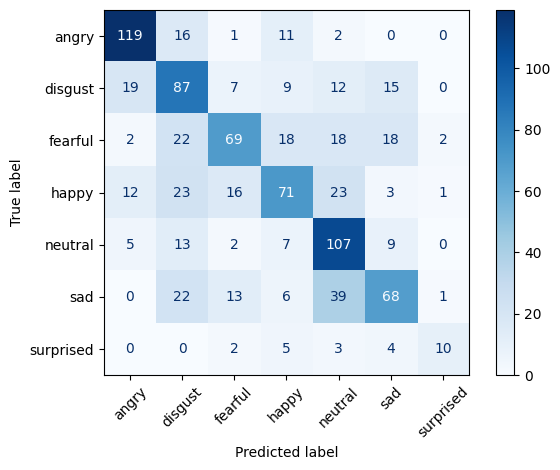

In [12]:
# Evaluación completa en test: reporte y matriz de confusión
y_true, y_pred = get_predictions(model, test_loader, device)
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(cmap='Blues', xticks_rotation=45)
plt.tight_layout()
plt.show()


## Modelos tradicionales de ML con Grid Search

Se entrenan **Random Forest** y **XGBoost** con búsqueda de hiperparámetros usando
`GridSearchCV` con `PredefinedSplit` para respetar la partición train/val sin filtrar
el set de test. Antes del entrenamiento se aplica **SMOTE** exclusivamente sobre el
conjunto de entrenamiento para balancear la clase minoritaria `surprised`.


In [7]:
def pack_to_numpy(pack):
    x = pack['x'].float().reshape(pack['x'].shape[0], -1).numpy()
    y = pack['y'].numpy()
    return x, y

X_train, y_train = pack_to_numpy(train_pack)
X_val, y_val = pack_to_numpy(val_pack)
X_test, y_test = pack_to_numpy(test_pack)
X_train_val = np.concatenate([X_train, X_val], axis=0)
y_train_val = np.concatenate([y_train, y_val], axis=0)


print(f"Muestras por clase:")
for cls, idx in sorted(class_to_idx.items(), key=lambda kv: kv[1]):
    print(f"  {cls:12s} (idx={idx}): {(y_train == idx).sum()}")

# -1 = train, 0 = val (PredefinedSplit usa índice de fold)
test_fold = np.concatenate([
    -1 * np.ones(len(X_train), dtype=int),
     np.zeros(len(X_val), dtype=int)
])
predefined_split = PredefinedSplit(test_fold)
print(f"\nTamaño total train+val para GridSearchCV: {len(X_train_val)}")
print(f"(train={len(X_train)}, val={len(X_val)}, test={len(X_test)} — test NO entra en GridSearch)")


Muestras por clase:
  angry        (idx=0): 1178
  disgust      (idx=1): 1178
  fearful      (idx=2): 1178
  happy        (idx=3): 1178
  neutral      (idx=4): 1100
  sad          (idx=5): 1178
  surprised    (idx=6): 432

Tamaño total train+val para GridSearchCV: 8258
(train=7422, val=836, test=912 — test NO entra en GridSearch)


In [15]:
# ── Random Forest con Grid Search ────────────────────────────────────────────
param_grid_rf = {
    'n_estimators': [100, 60],
    'max_depth': [20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['log2'],
}

rf = RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1)
grid_rf = GridSearchCV(
    rf,
    param_grid=param_grid_rf,
    cv=predefined_split,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1,
)
grid_rf.fit(X_train_val, y_train_val)

print('RF — Mejores parámetros:', grid_rf.best_params_)
print('RF — Mejor f1_macro (val):', grid_rf.best_score_)


Fitting 1 folds for each of 8 candidates, totalling 8 fits
RF — Mejores parámetros: {'max_depth': 20, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 60}
RF — Mejor f1_macro (val): 0.3372660860108813


=== Random Forest — Evaluación en Test ===
              precision    recall  f1-score   support

       angry       0.59      0.62      0.61       149
     disgust       0.32      0.26      0.28       149
     fearful       0.32      0.19      0.24       149
       happy       0.43      0.36      0.39       149
     neutral       0.36      0.48      0.41       143
         sad       0.46      0.50      0.48       149
   surprised       0.14      0.42      0.21        24

    accuracy                           0.40       912
   macro avg       0.37      0.40      0.37       912
weighted avg       0.41      0.40      0.40       912



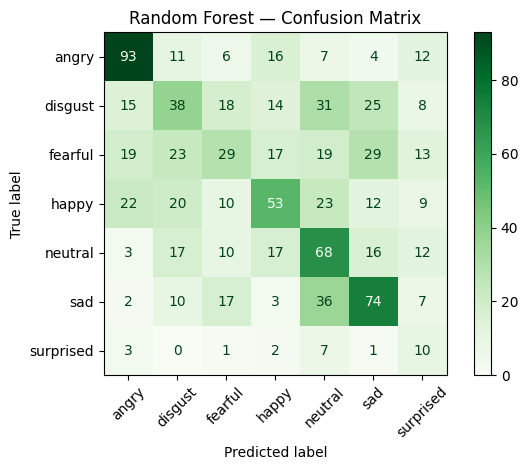

In [16]:
best_rf = RandomForestClassifier(**grid_rf.best_params_, random_state=42, class_weight='balanced', n_jobs=-1)
best_rf.fit(X_train_val, y_train_val)
y_pred_rf = best_rf.predict(X_test)
print('=== Random Forest — Evaluación en Test ===')
print(classification_report(y_test, y_pred_rf, target_names=class_names))

cm_rf = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(cm_rf, display_labels=class_names).plot(cmap='Greens', xticks_rotation=45)
plt.title('Random Forest — Confusion Matrix')
plt.tight_layout()
plt.show()

In [13]:
# ── XGBoost con Grid Search ───────────────────────────────────────────────────
param_grid_xgb = {
    'n_estimators': [30],
    'max_depth': [3],
    'learning_rate': [0.01],
    'subsample': [0.8],
    'colsample_bytree': [0.8],
}

xgb_clf = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=len(class_names),
    tree_method='hist',
    use_label_encoder=False,
    eval_metric='merror',
    random_state=42,
    n_jobs=-1,
)
grid_xgb = GridSearchCV(
    xgb_clf,
    param_grid=param_grid_xgb,
    cv=predefined_split,
    scoring='f1_macro',
    n_jobs=-1, # Changed from 1 to -1 to use all available cores
    verbose=1,
)
grid_xgb.fit(X_train_val, y_train_val)

print('XGB — Mejores parámetros:', grid_xgb.best_params_)
print('XGB — Mejor f1_macro (val):', grid_xgb.best_score_)

Fitting 1 folds for each of 1 candidates, totalling 1 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:51:10] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGB — Mejores parámetros: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 30, 'subsample': 0.8}
XGB — Mejor f1_macro (val): 0.29780300025493417


=== XGBoost — Evaluación en Test ===
              precision    recall  f1-score   support

       angry       0.47      0.68      0.55       149
     disgust       0.35      0.36      0.35       149
     fearful       0.31      0.20      0.24       149
       happy       0.33      0.38      0.35       149
     neutral       0.30      0.10      0.15       143
         sad       0.41      0.62      0.49       149
   surprised       0.00      0.00      0.00        24

    accuracy                           0.38       912
   macro avg       0.31      0.33      0.31       912
weighted avg       0.35      0.38      0.35       912



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


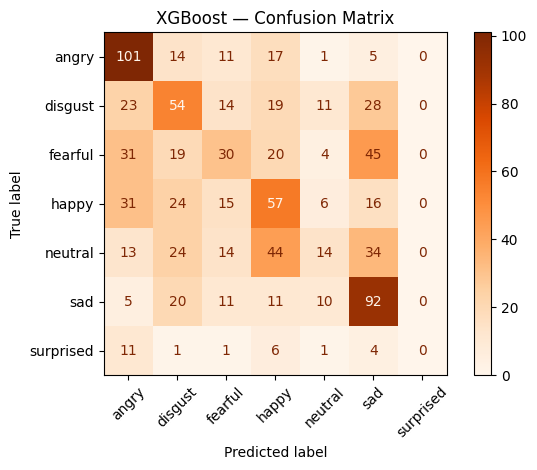

In [14]:
best_xgb = grid_xgb.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)
print('=== XGBoost — Evaluación en Test ===')
print(classification_report(y_test, y_pred_xgb, target_names=class_names))

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
ConfusionMatrixDisplay(cm_xgb, display_labels=class_names).plot(cmap='Oranges', xticks_rotation=45)
plt.title('XGBoost — Confusion Matrix')
plt.tight_layout()
plt.show()
